<div style='background: linear-gradient(90deg, #16324f, #1f6f78); padding: 24px; border-radius: 14px; color: white;'>
  <h1 style='margin:0;'> National scale Methane emissions calculation with Sentinel-5P</h1>
</div>

**Products used:** 
[s5p_tropomi_l2_ch4](https://explorer.digitalearth.africa/products/s5p_tropomi_l2_ch4)
[s5p_tropomi_l2_cloud](https://explorer.digitalearth.africa/products/s5p_tropomi_l2_cloud)
[ERA5](https://registry.opendata.aws/ecmwf-era5/)

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 12px; border-radius: 0px; color: white;">
  <h2 style="margin: 0;">Background</h2>
</div>

Sentinel-5P is a European Earth observation satellite launched in 2017 under the Copernicus Programme to monitor atmospheric composition and air quality. It carries the TROPOspheric Monitoring Instrument (TROPOMI), a hyperspectral sensor that measures trace gases such as methane (CH₄), nitrogen dioxide (NO₂), ozone (O₃), sulfur dioxide (SO₂), and carbon monoxide (CO). Methane retrievals are primarily derived from shortwave infrared (SWIR) spectral absorption measurements, enabling global observations of atmospheric methane concentrations with daily revisit capability[Sentinel-5 Precursor Level 2 Methane - Copernicus](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-5P/Sentinel-5P_data_used_in_new_methane_detection_system).

Methane is the second most important anthropogenic greenhouse gas after carbon dioxide and has a significantly higher warming potential over short time scales. Sentinel-5P methane products provide column-averaged dry-air mole fractions of methane (XCH₄), allowing researchers to monitor methane sources, sinks, and atmospheric transport processes at regional to global scales. The high spatial and temporal resolution of TROPOMI enables the identification of methane hotspots associated with oil and gas production, coal mining, landfills, wetlands, agriculture, and biomass burning [Sentinel-5 Precursor Level 2 Methane - Copernicus](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-5P/Sentinel-5P_data_used_in_new_methane_detection_system).

The Sentinel-5P methane dataset has become an important resource for climate science, greenhouse gas inventories, and environmental policy assessment. Its near-daily global coverage supports the detection of large methane leaks and “super-emitters,” improving the understanding of emission dynamics and supporting mitigation strategies. The dataset is also widely integrated with higher-resolution satellite observations, atmospheric models, and ground-based measurements to enhance emission quantification and validation. This capability has significantly advanced operational methane monitoring for climate change research and international climate reporting frameworks [Sentinel-5P data used in new methane detection system](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-5P/Sentinel-5P_data_used_in_new_methane_detection_system).



<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;">Sentinel-5P TROPOMI Level-2 Methane</h3>
</div>

**Methane (CH₄) Column-Averaged Mixing Ratio** measures the vertically integrated concentration of methane in the atmosphere and is used to identify major greenhouse gas emission sources and support climate change research.
***

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 12px; border-radius: 0px; color: white;">
  <h2 style="margin: 0;">Description</h2>
</div>

This notebook will cover following topics:

1. Inspecting the products and measurements available in the datacube
2. Loading Sentinel-5P_*** Datasets.
3. Plotting the results
4. ERA5 Climate Gridded Data

***

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 12px; border-radius: 0px; color: white;">
  <h2 style="margin: 0;">Getting started</h2>
</div>

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;">Load packages</h3>
</div>

Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import numpy as np
import xarray as xr
import pandas as pd
import datacube
import geopandas as gpd
import matplotlib.pyplot as plt
from odc.geo.geom import Geometry
from scipy.stats import gaussian_kde
from IPython.display import Markdown, display

from deafrica_tools.spatial import xr_rasterize
from deafrica_tools.plotting import display_map
from deafrica_tools.areaofinterest import define_area
from deafrica_tools.load_era5 import load_era5
from methane_convention import *

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;">Connect to the datacube</h3>
</div>

Connect to the datacube so we can access DE Africa data.

In [2]:
dc = datacube.Datacube(app="Sentinel_5P_methane")

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;">List measurements</h3>
</div>

Run the cell below to inspect he measurments of s5p_tropomi_l2_ch4, using the datacube's `list_measurements` functionality.

In [3]:
product = "s5p_tropomi_l2_ch4"
measurements = dc.list_measurements()
display(Markdown("**The table below lists the measurements available for the data**"))
measurements.loc[product]

**The table below lists the measurements available for the data**

,name,dtype,units,nodata,aliases,flags_definition,add_offset,scale_factor
measurement,,,,,,,,
CH4,CH4,float32,ppb,-9999.0,NaN,NaN,0.0,1.0
dataMask,dataMask,uint8,1,255.0,NaN,NaN,0.0,1.0


<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;">Analysis parameters</h3>
</div>

The following cell sets the parameters, which define the area of interest to conduct the analysis over.
#### Select location
To define the area of interest, there are two methods available:

1. By specifying the latitude, longitude, and buffer, or separate latitude and longitude buffers, this method allows you to define an area of interest around a central point. You can input the central latitude, central longitude, and a buffer value in degrees to create a square area around the center point. For example, `lat = 10.338`, `lon = -1.055`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates `(10.338, -1.055)`. 
    
    Alternatively, you can provide separate buffer values for latitude and longitude for a rectangular area. For example, `lat = 10.338`, `lon = -1.055`, and `lat_buffer = 0.1` and`lon_buffer = 0.08` will select a rectangular area extending 0.1 degrees north and south, and 0.08 degrees east and west from the point `(10.338, -1.055)`.

   For reasonable loading times, set the buffer as `0.1` or lower.

3. By uploading a polygon as a `GeoJSON or Esri Shapefile`. If you choose this option, you will need to upload the geojson or ESRI shapefile into the Sandbox using Upload Files button <img align="top" src="../Supplementary_data/upload_files_icon.png"> in the top left corner of the Jupyter Notebook interface. ESRI shapefiles must be uploaded with all the related files `(.cpg, .dbf, .shp, .shx)`. Once uploaded, you can use the shapefile or geojson to define the area of interest. Remember to update the code to call the file you have uploaded.

To use one of these methods, you can uncomment the relevant line of code and comment out the other one. To comment out a line, add the `"#"` symbol before the code you want to comment out. By default, the first option which defines the location using latitude, longitude, and buffer is being used.

**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.

The example focuses on the Niger Delta region of Nigeria, one of Africa’s most significant methane emission hotspots associated with oil and gas production, gas flaring, pipelines, refineries, wetlands, and urban-industrial activities. The region exhibits strong atmospheric methane signals detectable by Sentinel-5P TROPOMI, alongside emissions from biomass burning and other trace gases linked to energy production and environmental degradation. Due to persistent industrial activity and relatively consistent atmospheric observations during the dry season, the Niger Delta provides an ideal demonstration site for evaluating the capabilities of Sentinel-5P Level-2 methane products under complex and dynamic environmental conditions.

**To run the notebook for a different area**, make sure Sentinel-5 Precursor’s TROPOMI data is available for the chosen area using the [DEAfrica Explorer](https://explorer.digitalearth.africa).

In [4]:
# Method 1: Specify the latitude, longitude, and buffer)
# aoi = define_area(lat=5.5, lon=6.5, buffer=1)

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile.
# Download the Ghana.geojson file from https://drive.google.com/drive/folders/1rzmvDGPT2Tq-w1a_hPQNr2p0kJ3PS-kt into the directory where this notebook is located
aoi = define_area(vector_path='Ghana.geojson')


#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

In [5]:
display_map(x=lon_range, y=lat_range)

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;">Accessing Sentinel 5P data through DE Africa</h3>
</div>

Now that we know what products and measurements are available for the product, we can load data from the datacube using `dc.load`. We will load data from spectral satellite bands. By specifying `output_crs='EPSG:4326'` and `resolution=(-0.01, 0.01`), we are loading data in its native projection and resolution. Finally, `group_by='solar_day'` ensures that overlapping images taken within seconds of each other as the satellite passes over are combined into a single time step in the data. The query defined below will be used for all the other products.

In [6]:
time_start = "2025-01-01"
time_end = "2025-01-31"
query = {
    'x': (lon_range),
    'y': (lat_range),
    'time':(time_start, time_end),
    'output_crs': 'EPSG:4326',
    'resolution': (-0.01, 0.01)}

In [7]:
query

{'x': (np.float64(-3.262085), np.float64(1.200317)),
 'y': (np.float64(4.740723), np.float64(11.174683)),
 'time': ('2025-01-01', '2025-01-31'),
 'output_crs': 'EPSG:4326',
 'resolution': (-0.01, 0.01)}

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;">Sentinel-5P TROPOMI Level-2 Methane (CH₄) Column-Averaged Mixing Ratio</h3>
</div>

Sentinel-5P TROPOMI Level-2 Methane (CH₄) Column-Averaged Mixing Ratio is a satellite product from Sentinel-5 Precursor’s TROPOMI that measures the vertically integrated amount of methane in the atmosphere by analyzing reflected shortwave-infrared sunlight. It is used to detect and map methane emission hotspots, quantify regional sources from oil and gas operations, agriculture and wetlands, monitor trends in a major greenhouse gas, and support climate policy and mitigation efforts.

In [8]:
ds_l2_ch4 = dc.load(product='s5p_tropomi_l2_ch4',
                    group_by="solar_day", 
                    **query)

ds_l2_ch4

<xarray.Dataset> Size: 45MB
Dimensions:      (time: 31, latitude: 644, longitude: 448)
Coordinates:
  * time         (time) datetime64[ns] 248B 2025-01-01T05:53:15 ... 2025-01-3...
  * latitude     (latitude) float64 5kB 11.17 11.16 11.15 ... 4.765 4.755 4.745
  * longitude    (longitude) float64 4kB -3.265 -3.255 -3.245 ... 1.195 1.205
    spatial_ref  int32 4B 4326
Data variables:
    CH4          (time, latitude, longitude) float32 36MB nan nan ... nan nan
    dataMask     (time, latitude, longitude) uint8 9MB 0 0 0 0 0 0 ... 0 0 0 0 0
Attributes:
    crs:           EPSG:4326
    grid_mapping:  spatial_ref

#### Masking

Before visualisation, we use the `dataMask` band to mask values affected by cloud or other issues. The code below keeps data for pixels where the data mask value is 1.

In [9]:
ds_l2_ch4 = ds_l2_ch4.where(ds_l2_ch4.dataMask == 1)

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;">Convert Daily Methane Data to Monthly Statistics</h3>
</div>

| Statistic   | When to use                                            | Meaning                                   |
| ----------- | ------------------------------------------------------ | ----------------------------------------- |
| **mean**    | Best for general monthly average methane concentration | Average CH₄ value for the month           |
| **median**  | Best when there are outliers or extreme plume values   | Typical CH₄ condition for the month       |
| **maximum** | Best for hotspot or plume detection                    | Highest CH₄ value observed in the month   |
| **count**   | Good for quality checking                              | Number of valid observations in the month |

For this example,the maximum value `max` for the monthly aggregation will be used. However, depending on the purpose of the analysis, users can also use other statistics such as `mean`, `median`, or `count`

In [10]:
ds_l2_ch4 = ds_l2_ch4.resample(time="1MS").max(skipna=True)

In [11]:
#Mask the rainfall dataset using the country boundary
mask = xr_rasterize(geopolygon_gdf, ds_l2_ch4)

#mask  dataset
ds_l2_ch4 = ds_l2_ch4.where(mask)

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h4 style="margin: 0;">Visualising the band</h4>
</div>

Methane (CH₄) is a potent greenhouse gas emitted by wetlands, livestock, oil and gas production, landfills, and rice fields. Sentinel-5P measures CH₄ in parts per billion (PPB). It plays a major role in climate warming and atmospheric chemical reactions.

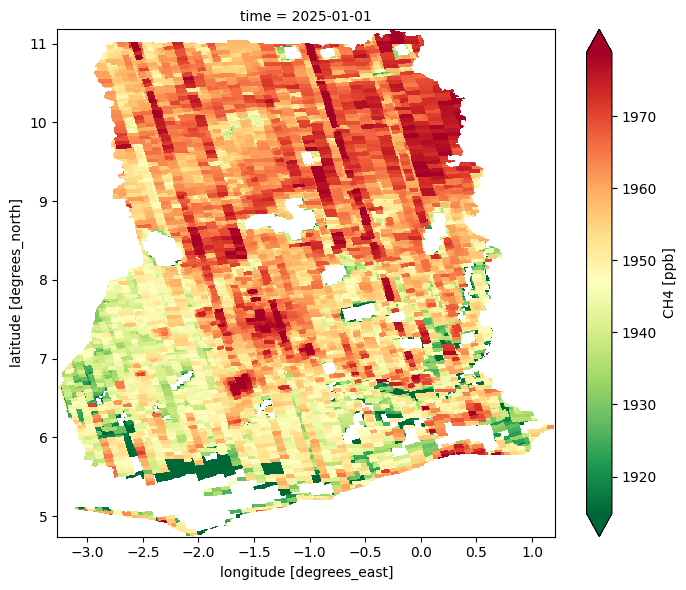

In [12]:
ds_l2_ch4['CH4'].plot(robust=True, col="time", size=6, cmap='RdYlGn_r')

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;"> Load ERA5 Climate Gridded Data</h3>
</div>

ERA5 surface pressure is required in Sentinel-5P methane analysis because methane retrievals are provided as column-averaged dry-air mole fractions (XCH₄) in parts per billion (ppb), which depend on the total atmospheric air mass and pressure structure above the Earth’s surface. Surface pressure data enables the conversion of methane concentrations from ppb into physical quantities such as molar concentration, mass density, and total methane mass in tonnes using atmospheric relationships such as the ideal gas law, while also improving consistency and reducing uncertainties associated with elevation and meteorological variability.

The cell below loads the surface pressure variable for the study area.

In [13]:
# Loading surface pressure from ERA 1
surface_pressure = load_era5('surface_pressure', lat_range, lon_range, query['time'], chunks=None, resample='1ME')

Opening ERA5 Zarr dataset...
Variable: surface_pressure
Mapped ERA5 name: surface_pressure
Time: 2025-01-01 to 2025-01-31
Latitude: 4.740723 to 11.174683
Longitude: -3.2620850000000132 to 1.2003170000000125
Selecting time range...
Normalising longitude coordinates...
Selecting AOI...
Subset size: {'time': 744, 'latitude': 27, 'longitude': 19}
Resampling to 1ME using mean...
ERA5 loading complete.


<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;"> Converting Sentinel-5P Methane from ppb to Atmospheric Methane Mass</h3>
</div>

Sentinel-5P methane products provide XCH₄ as **vertical column-averaged** dry-air mole fractions in **parts per billion (ppb)**, representing the average methane concentration within the atmospheric column above each satellite pixel. To support mass and emission analysis, these ppb values can be converted into methane mass per unit area and total methane mass by combining the methane enhancement with surface pressure, atmospheric constants, and pixel area.

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h4 style="margin: 0;"> Why Convert Methane from ppb to Mass-Based Units?</h4>
</div>


* These units make methane results easier to understand.

* They help identify methane hotspots and emission sources.

* They support climate reporting and greenhouse gas inventories.

* They are useful for comparing dates, regions, and events.

* With wind speed and plume length, total tonnes can support emission-rate estimates.


---
<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h4 style="margin: 0;"> Molecular Weights Used in the Conversion</h4>
</div>


The molecular weight determines how many grams one mole of a gas weighs:

| Gas | Molecular Weight (g/mol) |
|-----|---------------------------|
| CH₄ (Methane) | 16.04 |

The value is provided to the conversion function so that any Sentinel-5P gas product can be processed consistently.

---

The function below performs the full conversion from **Sentinel-5P TROPOMI Level-2 methane observations** provided as **XCH₄ in parts per billion (ppb)** into mass-based methane products for your area of interest (AOI).

To run the calculation, you need to supply:

1. **The methane variable** from your dataset

   * `ch4_ppb` should be in ppb and represents the column-averaged dry-air mole fraction of methane.

2. **Surface pressure data**

   * `surface_pressure` should be in Pascals (Pa) and is used to estimate the dry-air column needed for the mass conversion.

3. **Pixel area**

   * `area_m2` should be in square metres and is used to convert methane mass per unit area into tonnes per pixel.

The function automatically:

* Estimates background methane using a selected method, such as a quantile background
* Calculates methane enhancement above background
* Converts ppb → kg/m² → tonnes per pixel → total tonnes
* Reports total methane mass, mean methane mass per unit area, and valid observation area

This allows Sentinel-5P methane observations to be transformed into physically meaningful mass-based units for methane hotspot analysis, emission assessment, climate studies, and environmental reporting.


In [14]:
# Make sure the dataset have the same lat and lon name
ds_l2_ch4 = rename_latlon(ds_l2_ch4)
surface_pressure = rename_latlon(surface_pressure)

ds_l2_ch4 = ds_l2_ch4['CH4']

The code below interpolates ERA5 surface pressure data to match the spatial coordinates (latitude and longitude) and observation times of the Sentinel-5P methane dataset using the nearest available values. This ensures that the surface pressure information is aligned with each methane observation for accurate atmospheric and methane mass calculations.

In [15]:
sp_pressure = surface_pressure["surface_pressure"].interp(
    time=ds_l2_ch4.time,
    lat=ds_l2_ch4.lat,
    lon=ds_l2_ch4.lon,
    method="nearest",
    kwargs={"fill_value": "extrapolate"}
)

The code calculates the surface area of each Sentinel-5P methane grid cell in square metres based on the dataset’s latitude and longitude coordinates. These grid-cell areas are required for converting methane concentrations into total methane mass or emission estimates in physical units such as tonnes.

In [16]:
area = gridcell_area_m2(ds_l2_ch4.lat, ds_l2_ch4.lon)

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;"> Why Background Methane Is Important</h3>
</div>

Background methane represents the normal methane concentration in the atmosphere before identifying any local enhancement or plume. It is important because Sentinel-5P measures the total methane concentration in the atmospheric column, which includes both natural/background methane and additional methane from possible emission sources.

By subtracting the background, the function estimates **methane enhancement**, which is the extra methane above normal atmospheric levels. This is useful for detecting methane hotspots, plumes, and possible emission events.

The background setting affects the type of result the user will get:

* `background="quantile"`: The function estimates a background value from the data, such as the 5th percentile. The output represents **excess methane above background**, which is useful for plume and hotspot detection.

* `background=None`: No background is removed. The output represents the **total atmospheric methane column mass**, including both background methane and any enhancement.

* `background=1900`: A fixed background value in ppb is removed. The output represents methane enhancement above a known or assumed regional background.

* `background=my_background`: A custom background dataset is used, such as an upwind area or monthly baseline. This gives more control when a specific reference condition is needed.

>Using a background helps separate the normal methane already present in the atmosphere from the additional methane that may come from local emission sources. Outputs represent methane enhancement when a background is specified. If background=None and quantile=0, they represent the total methane column instead.

The cell below uses a density plot to show how the 5th percentile methane background value is identified.

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h3 style="margin: 0;"> How the ppb Density Plot and 5th Quantile Work</h3>
</div>

The density plot shows the distribution of Sentinel-5P methane values measured in **parts per billion (ppb)** across the study area. Each pixel has a methane value, and the plot shows how common or uncommon those values are.

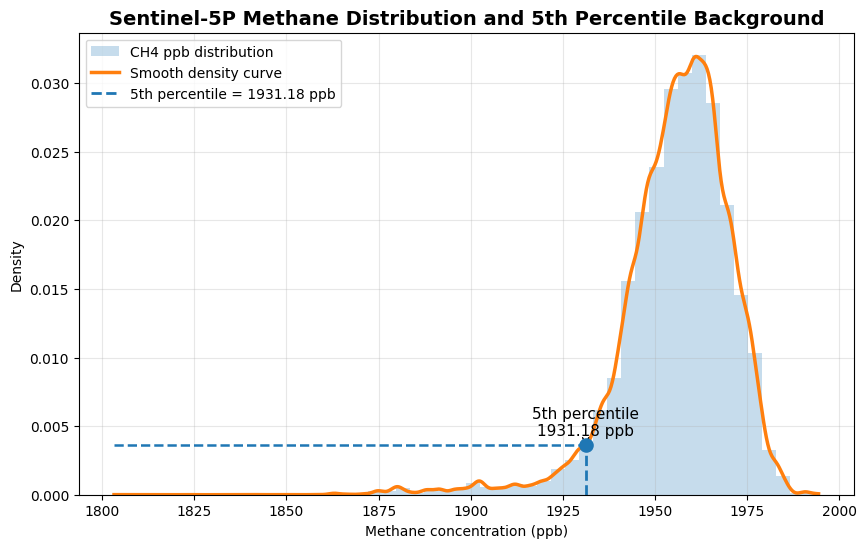

5th percentile methane background: 1931.18 ppb
Using the 5th percentile is better than using the minimum value because the minimum may be affected by noise, poor retrievals, or outlier pixels.
For example, if the 5th percentile is 1931.176513671875, t means that only 5% of the methane pixels have values at or below this level. This value is used as an estimate of the background methane concentration because it represents the lower methane values in the study area.


In [17]:
q05_ppb = plot_density(
    ch4_ppb=ds_l2_ch4,
    quantile=0.05,
    time_index=0,
    title="Sentinel-5P Methane Distribution and 5th Percentile Background"
)

print(f'Using the 5th percentile is better than using the minimum value because the minimum may be affected by noise, poor retrievals, or outlier pixels.') 
print(f'For example, if the 5th percentile is {q05_ppb}, t means that only 5% of the methane pixels have values at or '
      f'below this level. This value is used as an estimate of the background methane concentration because it represents the lower methane values in the study area.')

The **x-axis** shows methane concentration in **ppb**. Lower methane values appear on the left side of the graph, while higher methane values appear on the right side. The **y-axis** shows density, which means how strongly the ppb values are concentrated around a certain range. The smooth bell-shaped curve helps show where most methane values are found. The highest part of the curve represents the ppb range where most pixels occur. The vertical dashed line on the plot marks this 5th percentile methane value. This value is used as the **background methane concentration** when `background="quantile"` and `background_quantile=0.05`. The point on the curve shows where the 5th percentile ppb value meets the density curve. This helps the user visually identify the selected background methane value from the distribution.The plot helps us to see the methane background value before converting methane enhancement into **kg/m²**, **tonnes per pixel**, and **total tonnes**.

For the cell below, `background="quantile"` means the background methane concentration is estimated using a selected percentile of the methane observations. The setting `background_quantile=0.05` means the function uses the **5th percentile** methane value as the background concentration.

In [18]:
ch4_mass = convert_ch4(
    ch4_ppb=ds_l2_ch4,
    surface_pressure=sp_pressure,
    area_m2=area,
    background=None,
    background_quantile=0,
    spatial_dims=("lat", "lon"),
    clip_negative=True
)

ch4_mass

<xarray.Dataset> Size: 9MB
Dimensions:           (lat: 644, lon: 448, time: 1)
Coordinates:
  * lat               (lat) float64 5kB 11.17 11.16 11.15 ... 4.765 4.755 4.745
  * lon               (lon) float64 4kB -3.265 -3.255 -3.245 ... 1.195 1.205
  * time              (time) datetime64[ns] 8B 2025-01-01
    spatial_ref       int32 4B 4326
Data variables:
    background_ppb    (time, lat, lon) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    delta_ppb         (time, lat, lon) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ch4_mol_m2        (time, lat, lon) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ch4_kg_m2         (time, lat, lon) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ch4_g_m2          (time, lat, lon) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ch4_tonnes_km2    (time, lat, lon) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tonnes_per_pixel  (time, lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    total_tonnes      (time) float64 8B 2.406e+06
    total_kg          (time) float64 8B 2.406e+09
    mean_kg_m2        (time) float64 8B 0.006813
    valid_area_m2     (time) float64 8B 3.531e+11
    total_mol         (time) float64 8B 1.5e+11
Attributes:
    mass_type:            total_column
    background:           None
    background_quantile:  0
    note:                 For emission studies, use methane enhancement above...

In [19]:
df_results = (
    ch4_mass[["total_tonnes", "total_kg", "mean_kg_m2", "valid_area_m2"]]
    .to_dataframe()
    .reset_index()
    .rename(columns={"time": "timestep"})
)

df_results["total_tonnes"] = df_results["total_tonnes"].round(2)
df_results["total_kg"] = df_results["total_kg"].round(2)
df_results["mean_kg_m2"] = df_results["mean_kg_m2"].round(8)

df_results

,timestep,total_tonnes,total_kg,mean_kg_m2,valid_area_m2,spatial_ref
0,2025-01-01,2405683.09,2.405683e+09,0.006813,3.531022e+11,4326


Definiton of the variables:

| Variable        |          Unit | Meaning                                                                                                                                                     |
| --------------- | ------------: | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `total_tonnes`  |    tonnes CH₄ | Total methane mass over the study area for each timestep. This is calculated by summing methane mass from all valid pixels.                                 |
| `total_kg`      | kilograms CH₄ | Same as `total_tonnes`, but expressed in kilograms. Since 1 tonne = 1,000 kg, `total_kg = total_tonnes × 1000`.                                             |
| `mean_kg_m2`    |     kg CH₄/m² | Average methane mass loading per square metre over the valid study area. This is useful for comparing methane intensity between different dates or regions. |
| `valid_area_m2` |            m² | Total area of pixels that contain valid methane observations after masking, such as cloud masking or quality filtering.                                     |

>Important note: if your function uses background="quantile", then these values represent excess methane above background, not the full atmospheric methane column. So total_tonnes means total excess CH₄ mass, and mean_kg_m2 means average excess CH₄ mass loading.

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h2 style="margin: 0;"> Conclusion </h2>
</div>

Through Digital Earth Africa, methane data from the Sentinel-5P TROPOMI instrument are transforming access to atmospheric greenhouse gas information across Africa by providing analysis-ready observations of atmospheric methane concentrations. DE Africa reduces technical barriers to satellite data access through open data services, cloud-based processing, and scalable analytical tools, enabling researchers, institutions, and governments to monitor methane emissions from sources such as oil and gas activities, wetlands, landfills, agriculture, and biomass burning without requiring advanced computational infrastructure. Converting methane concentrations from parts per billion (ppb) into physical quantities such as tonnes is important because it enables estimation of the actual methane mass released into the atmosphere, supports greenhouse gas inventories and emission reporting, and improves climate mitigation planning, environmental governance, and policy decision-making aligned with the United Nations Sustainable Development Goals and the African Union Agenda 2063.

<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h2 style="margin: 0;"> References </h2>
</div>

The methane mass conversion and emission-estimation approach used in this notebook is based on the dry-air column relationship for methane column-averaged dry-air mole fraction (XCH₄), together with common practices for quantifying methane plume mass and emissions from remote sensing observations.

1. Worden, J., Green, P., Eldering, A., & Sherwin, E. (2025). *Common Practices for Quantifying Methane Emissions from Plumes Detected by Remote Sensing*. NIST Interagency Report NIST IR 8575. National Institute of Standards and Technology. https://doi.org/10.6028/NIST.IR.8575

2. Poursanidis, K., Sharanik, J., & Hadjistassou, C. (2024). *World’s largest natural gas leak from Nord Stream pipeline estimated at 478,000 tonnes*. iScience, 27(1), Article 108772. https://doi.org/10.1016/j.isci.2023.108772

3. Apituley, A., Pedergnana, M., Sneep, M., Veefkind, J. P., Loyola, D., Hasekamp, O., Lorente Delgado, A., & Borsdorff, T. (2022). *Sentinel-5 precursor/TROPOMI Level 2 Product User Manual: Methane*. SRON-S5P-LEV2-MA-001, Issue 2.4.0. ESA/Copernicus. https://sentinels.copernicus.eu/documents/247904/2474726/Sentinel-5P-Level-2-Product-User-Manual-Methane.pdf

4. Varon, D. J., Jacob, D. J., McKeever, J., Jervis, D., Durak, B. O. A., Xia, Y., & Huang, Y. (2018). *Quantifying methane point sources from fine-scale satellite observations of atmospheric methane plumes*. Atmospheric Measurement Techniques, 11, 5673–5686. https://doi.org/10.5194/amt-11-5673-2018

---
<div style="background: linear-gradient(90deg, #4a4a4a, #8a8a8a); padding: 10px; border-radius: 0px; color: white;">
  <h2 style="margin: 0;"> Additional information </h2>
</div>

<b> License </b> The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

<b> Contact </b> If you need assistance, please post a question on the [DE Africa Slack channel](https://digitalearthafrica.slack.com/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).

If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

<b> Compatible datacube version </b>

In [22]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [23]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-07-28'